**Amazon Sales Dataset**

**Dataset Columns Names**

**Features**
product_id - Product ID
product_name - Name of the Product
category - Category of the Product
discounted_price - Discounted Price of the Product
actual_price - Actual Price of the Product
discount_percentage - Percentage of Discount for the Product
rating - Rating of the Product
rating_count - Number of people who voted for the Amazon rating
about_product - Description about the Product
user_id - ID of the user who wrote review for the Product
user_name - Name of the user who wrote review for the Product
review_id - ID of the user review
review_title - Short review
review_content - Long review
img_link - Image Link of the Product
product_link - Official Website Link of the Product

**Objectives**

1. Data Cleaning & Pipeline Normalisation Clean messy raw fields and handling missing values to establish an analytics-ready database.

2. Pricing & Discounting Efficiency Analysis Analyse the relationship between discount levels (discount_percentage), customer satisfaction (rating), and market demand proxy (rating_count) to evaluate discount efficiency and identify unprofitable "discount traps."

3. Pareto (ABC) Category & SKU Segmentation Apply Pareto (80/20) Analysis on product categories and individual SKUs using estimated revenue (discounted_price * rating_count) to identify core revenue drivers versus long-tail items.

4. Commercial Strategy & Portfolio Optimization Translate quantitative findings into actionable insights for e-commerce merchants to optimize pricing strategy, protect profit margins, and enhance promotional ROI.

**Questions**
1. What is the average rating for each product category?
2. What are the top rating_count products by category?
3. What is the distribution of discounted prices vs. actual prices?
4. How does the average discount percentage vary across categories?
5. What are the most popular product name?
6. What are the most popular product keywords?
7. What are the most popular product reviews?
8. What is the correlation between discounted_price and rating?
9. What are the Top 5 categories based with highest ratings?
10. Does the review volume (rating_count) follow the Pareto 80/20 principle across categories?

In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy as sp
# this is for jupyter notebook to show the plot in the notebook itself instead of opening a new window
#%matplotlib inline

**Step 1: Data Loading and Cleaning**

Load a CSV file then creating a dataframe

In [56]:
df = pd.read_csv("amazon.csv")

Set the option to show maximum columns

In [57]:
pd.set_option('display.max_columns', None)

Get a quick review

In [58]:
df.head(5)

,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content,img_link,product_link
0,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories|Accessories&Peripherals|...,₹399,"₹1,099",64%,4.2,"24,269",High Compatibility : Compatible With iPhone 12...,"AG3D6O4STAQKAY2UVGEUV46KN35Q,AHMY5CWJMMK5BJRBB...","Manav,Adarsh gupta,Sundeep,S.Sayeed Ahmed,jasp...","R3HXWT0LRP0NMF,R2AJM3LFTLZHFO,R6AQJGUP6P86,R1K...","Satisfied,Charging is really fast,Value for mo...",Looks durable Charging is fine tooNo complains...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Wayona-Braided-WN3LG1-Sy...
1,B098NS6PVG,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,Computers&Accessories|Accessories&Peripherals|...,₹199,₹349,43%,4.0,"43,994","Compatible with all Type C enabled devices, be...","AECPFYFQVRUWC3KGNLJIOREFP5LQ,AGYYVPDD7YG7FYNBX...","ArdKn,Nirbhay kumar,Sagar Viswanathan,Asp,Plac...","RGIQEG07R9HS2,R1SMWZQ86XIN8U,R2J3Y1WL29GWDE,RY...","A Good Braided Cable for Your Type C Device,Go...",I ordered this cable to connect my phone to An...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Ambrane-Unbreakable-Char...
2,B096MSW6CT,Sounce Fast Phone Charging Cable & Data Sync U...,Computers&Accessories|Accessories&Peripherals|...,₹199,"₹1,899",90%,3.9,"7,928",【 Fast Charger& Data Sync】-With built-in safet...,"AGU3BBQ2V2DDAMOAKGFAWDDQ6QHA,AESFLDV2PT363T2AQ...","Kunal,Himanshu,viswanath,sai niharka,saqib mal...","R3J3EQQ9TZI5ZJ,R3E7WBGK7ID0KV,RWU79XKQ6I1QF,R2...","Good speed for earlier versions,Good Product,W...","Not quite durable and sturdy,https://m.media-a...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Sounce-iPhone-Charging-C...
3,B08HDJ86NZ,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,Computers&Accessories|Accessories&Peripherals|...,₹329,₹699,53%,4.2,"94,363",The boAt Deuce USB 300 2 in 1 cable is compati...,"AEWAZDZZJLQUYVOVGBEUKSLXHQ5A,AG5HTSFRRE6NL3M5S...","Omkar dhale,JD,HEMALATHA,Ajwadh a.,amar singh ...","R3EEUZKKK9J36I,R3HJVYCLYOY554,REDECAZ7AMPQC,R1...","Good product,Good one,Nice,Really nice product...","Good product,long wire,Charges good,Nice,I bou...",https://m.media-amazon.com/images/I/41V5FtEWPk...,https://www.amazon.in/Deuce-300-Resistant-Tang...
4,B08CF3B7N1,Portronics Konnect L 1.2M Fast Charging 3A 8 P...,Computers&Accessories|Accessories&Peripherals|...,₹154,₹399,61%,4.2,"16,905",[CHARGE & SYNC FUNCTION]- This cable comes wit...,"AE3Q6KSUK5P75D5HFYHCRAOLODSA,AFUGIFH5ZAFXRDSZH...","rahuls6099,Swasat Borah,Ajay Wadke,Pranali,RVK...","R1BP4L2HH9TFUP,R16PVJEXKV6QZS,R2UPDB81N66T4P,R...","As good as original,Decent,Good one for second...","Bought this instead of original apple, does th...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Portronics-Konnect-POR-1...


Column Names

In [59]:
df.columns

Index(['product_id', 'product_name', 'category', 'discounted_price',
       'actual_price', 'discount_percentage', 'rating', 'rating_count',
       'about_product', 'user_id', 'user_name', 'review_id', 'review_title',
       'review_content', 'img_link', 'product_link'],
      dtype='str')

Let's have a look on the shape of the dataset

In [60]:
print(f"The Number of Rows are {df.shape[0]}, and columns are {df.shape[1]}.")

The Number of Rows are 1465, and columns are 16.


Let's have a look on the columns and their data types using detailed info function

In [61]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1465 entries, 0 to 1464
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   product_id           1465 non-null   str  
 1   product_name         1465 non-null   str  
 2   category             1465 non-null   str  
 3   discounted_price     1465 non-null   str  
 4   actual_price         1465 non-null   str  
 5   discount_percentage  1465 non-null   str  
 6   rating               1465 non-null   str  
 7   rating_count         1463 non-null   str  
 8   about_product        1465 non-null   str  
 9   user_id              1465 non-null   str  
 10  user_name            1465 non-null   str  
 11  review_id            1465 non-null   str  
 12  review_title         1465 non-null   str  
 13  review_content       1465 non-null   str  
 14  img_link             1465 non-null   str  
 15  product_link         1465 non-null   str  
dtypes: str(16)
memory usage: 183.3 KB


In [62]:
df.isnull().sum()

product_id             0
product_name           0
category               0
discounted_price       0
actual_price           0
discount_percentage    0
rating                 0
rating_count           2
about_product          0
user_id                0
user_name              0
review_id              0
review_title           0
review_content         0
img_link               0
product_link           0
dtype: int64

**Observation Set 1**

As we can see from above, there are some missing values in the dataset.

**Changing data types of column from object to float.**

In [63]:
# Changing the data type of discounted price and actual price

df['discounted_price'] = df['discounted_price'].str.replace("₹",'')
df['discounted_price'] = df['discounted_price'].str.replace(",",'')
df['discounted_price'] = df['discounted_price'].astype('float64')

df['actual_price'] = df['actual_price'].str.replace("₹",'')
df['actual_price'] = df['actual_price'].str.replace(",",'')
df['actual_price'] = df['actual_price'].astype('float64')

In [64]:
# Changing Datatype and values in Discount Percentage
# 1. Remove the '%' symbol and cast the column to float
df['discount_percentage'] = df['discount_percentage'].str.replace('%','').astype('float64')
# 2. Divide by 100 to convert percentage values into actual decimal proportions
df['discount_percentage'] = df['discount_percentage'] / 100

In [65]:
# Finding unusual string in rating column
df['rating'].value_counts()

rating
4.1    244
4.3    230
4.2    228
4.0    129
3.9    123
4.4    123
3.8     86
4.5     75
4       52
3.7     42
3.6     35
3.5     26
4.6     17
3.3     16
3.4     10
4.7      6
3.1      4
5.0      3
3.0      3
4.8      3
3.2      2
2.8      2
2.3      1
|        1
2        1
3        1
2.6      1
2.9      1
Name: count, dtype: int64

In [66]:
# Check the strange row
df.query('rating == "|"')

,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content,img_link,product_link
1279,B08L12N5H1,Eureka Forbes car Vac 100 Watts Powerful Sucti...,"Home&Kitchen|Kitchen&HomeAppliances|Vacuum,Cle...",2099.0,2499.0,0.16,|,992,No Installation is provided for this product|1...,"AGTDSNT2FKVYEPDPXAA673AIS44A,AER2XFSWNN4LAUCJ5...","Divya,Dr Nefario,Deekshith,Preeti,Prasanth R,P...","R2KKTKM4M9RDVJ,R1O692MZOBTE79,R2WRSEWL56SOS4,R...","Decent product,doesn't pick up sand,Ok ok,Must...","Does the job well,doesn't work on sand. though...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Eureka-Forbes-Vacuum-Cle...


By searching the product_id on amazon official website, I am able to know that the rating of this product is 3.9. So, I am going to give the item rating a 3.9 as well.

In [67]:
# Changing Rating Columns Data Type
df['rating'] = df['rating'].str.replace('|', '3.9').astype('float64')


In [68]:
# Changing 'rating_count' Column Data Type
df['rating_count'] = df['rating_count'].str.replace(',', '').astype('float64')

In [72]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1465 entries, 0 to 1464
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   product_id           1465 non-null   str    
 1   product_name         1465 non-null   str    
 2   category             1465 non-null   str    
 3   discounted_price     1465 non-null   float64
 4   actual_price         1465 non-null   float64
 5   discount_percentage  1465 non-null   float64
 6   rating               1465 non-null   float64
 7   rating_count         1463 non-null   float64
 8   about_product        1465 non-null   str    
 9   user_id              1465 non-null   str    
 10  user_name            1465 non-null   str    
 11  review_id            1465 non-null   str    
 12  review_title         1465 non-null   str    
 13  review_content       1465 non-null   str    
 14  img_link             1465 non-null   str    
 15  product_link         1465 non-null   str    
dtyp

**Descriptive Statistics**

In [73]:
df.describe()

,discounted_price,actual_price,discount_percentage,rating,rating_count
count,1465.000000,1465.000000,1465.000000,1465.000000,1463.000000
mean,3125.310874,5444.990635,0.476915,4.096451,18295.541353
std,6944.304394,10874.826864,0.216359,0.291620,42753.864952
min,39.000000,39.000000,0.000000,2.000000,2.000000
25%,325.000000,800.000000,0.320000,4.000000,1186.000000
50%,799.000000,1650.000000,0.500000,4.100000,5179.000000
75%,1999.000000,4295.000000,0.630000,4.300000,17336.500000
max,77990.000000,139900.000000,0.940000,5.000000,426973.000000


**Observation Data Set 2**

Initially, all columns were classified as the object data type. Therefore, some columns were converted to the float data type for further analysis. Based on the Python coding and the descriptive statistics generated using the `describe()` function, there are four numeric variables in the dataset.

**Dealing with the missing values**

**Missing Values**

In [74]:
df.isnull().sum().sort_values(ascending = False)

rating_count           2
product_id             0
product_name           0
category               0
discounted_price       0
actual_price           0
discount_percentage    0
rating                 0
about_product          0
user_id                0
user_name              0
review_id              0
review_title           0
review_content         0
img_link               0
product_link           0
dtype: int64

In [75]:
# Find missing values percentage in the data
round(df.isnull().sum() / len(df) * 100, 2).sort_values(ascending=False)

rating_count           0.14
product_id             0.00
product_name           0.00
category               0.00
discounted_price       0.00
actual_price           0.00
discount_percentage    0.00
rating                 0.00
about_product          0.00
user_id                0.00
user_name              0.00
review_id              0.00
review_title           0.00
review_content         0.00
img_link               0.00
product_link           0.00
dtype: float64

In [76]:
# Find total number of missing values
df.isnull().sum().sum()

np.int64(2)

**Let's plot the missing values**

<Axes: >

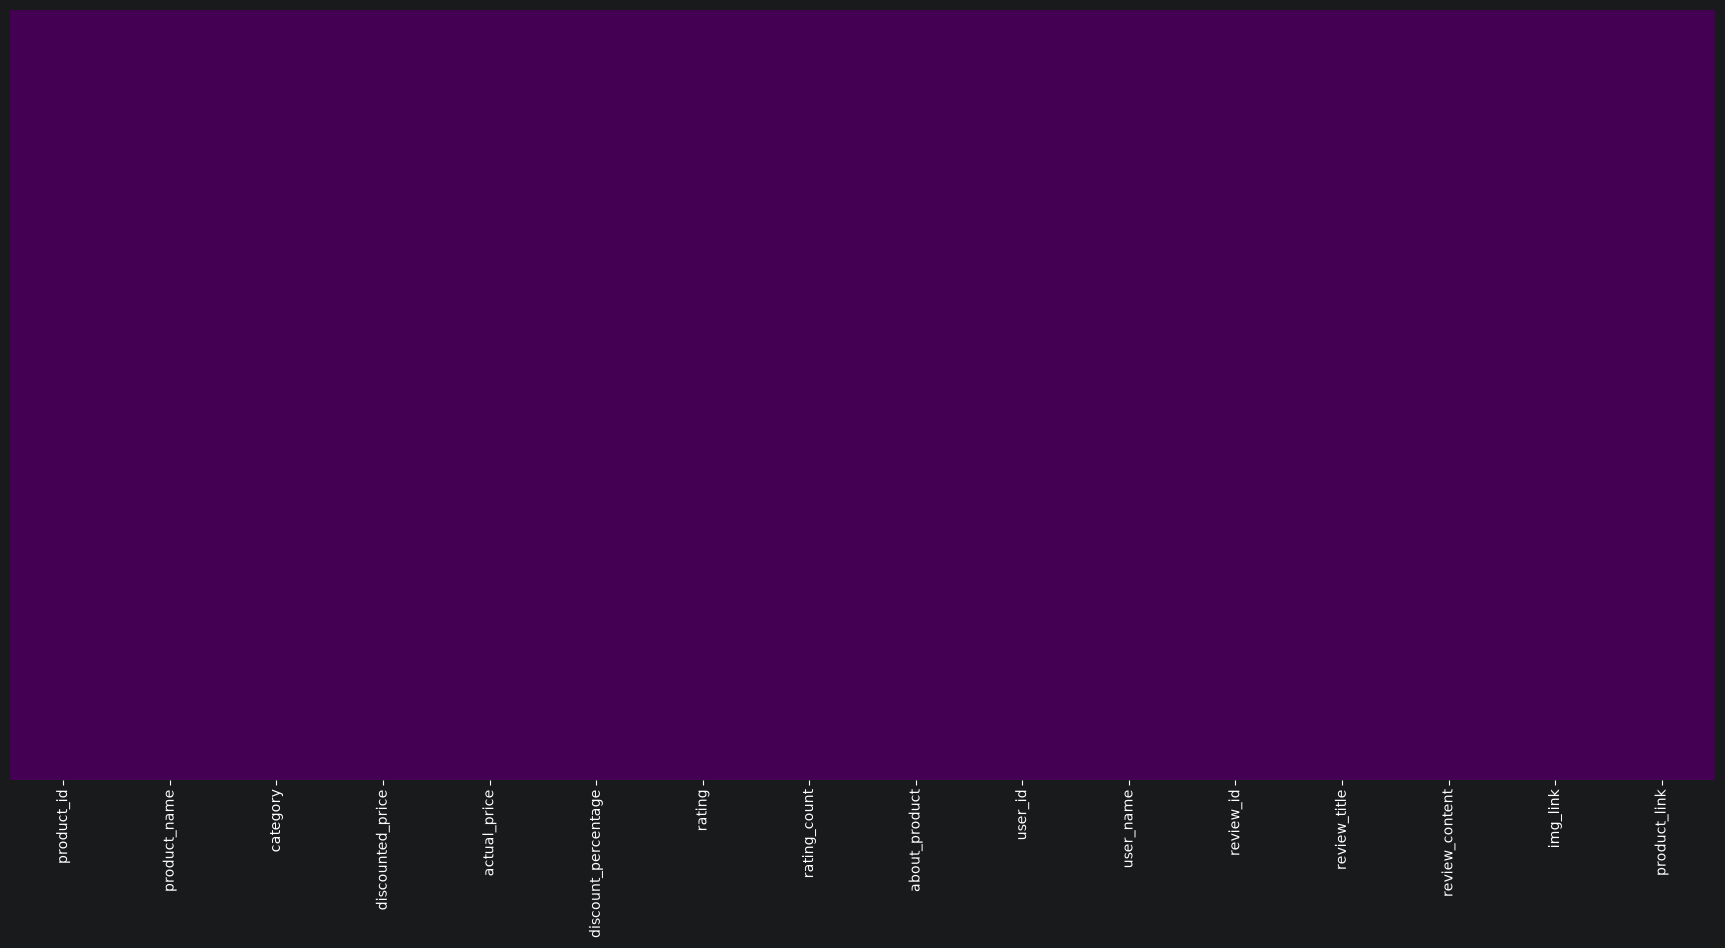

In [81]:
# make a figure size
plt.figure(figsize=(22, 10))
# plot the null values in each column
sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap='viridis')

With only two missing values (0.14% of the total dataset), the missingness is too negligible to be visible on the bar plot.

Text(0.5, 1.0, 'Percentage of Missing Values in each Column')

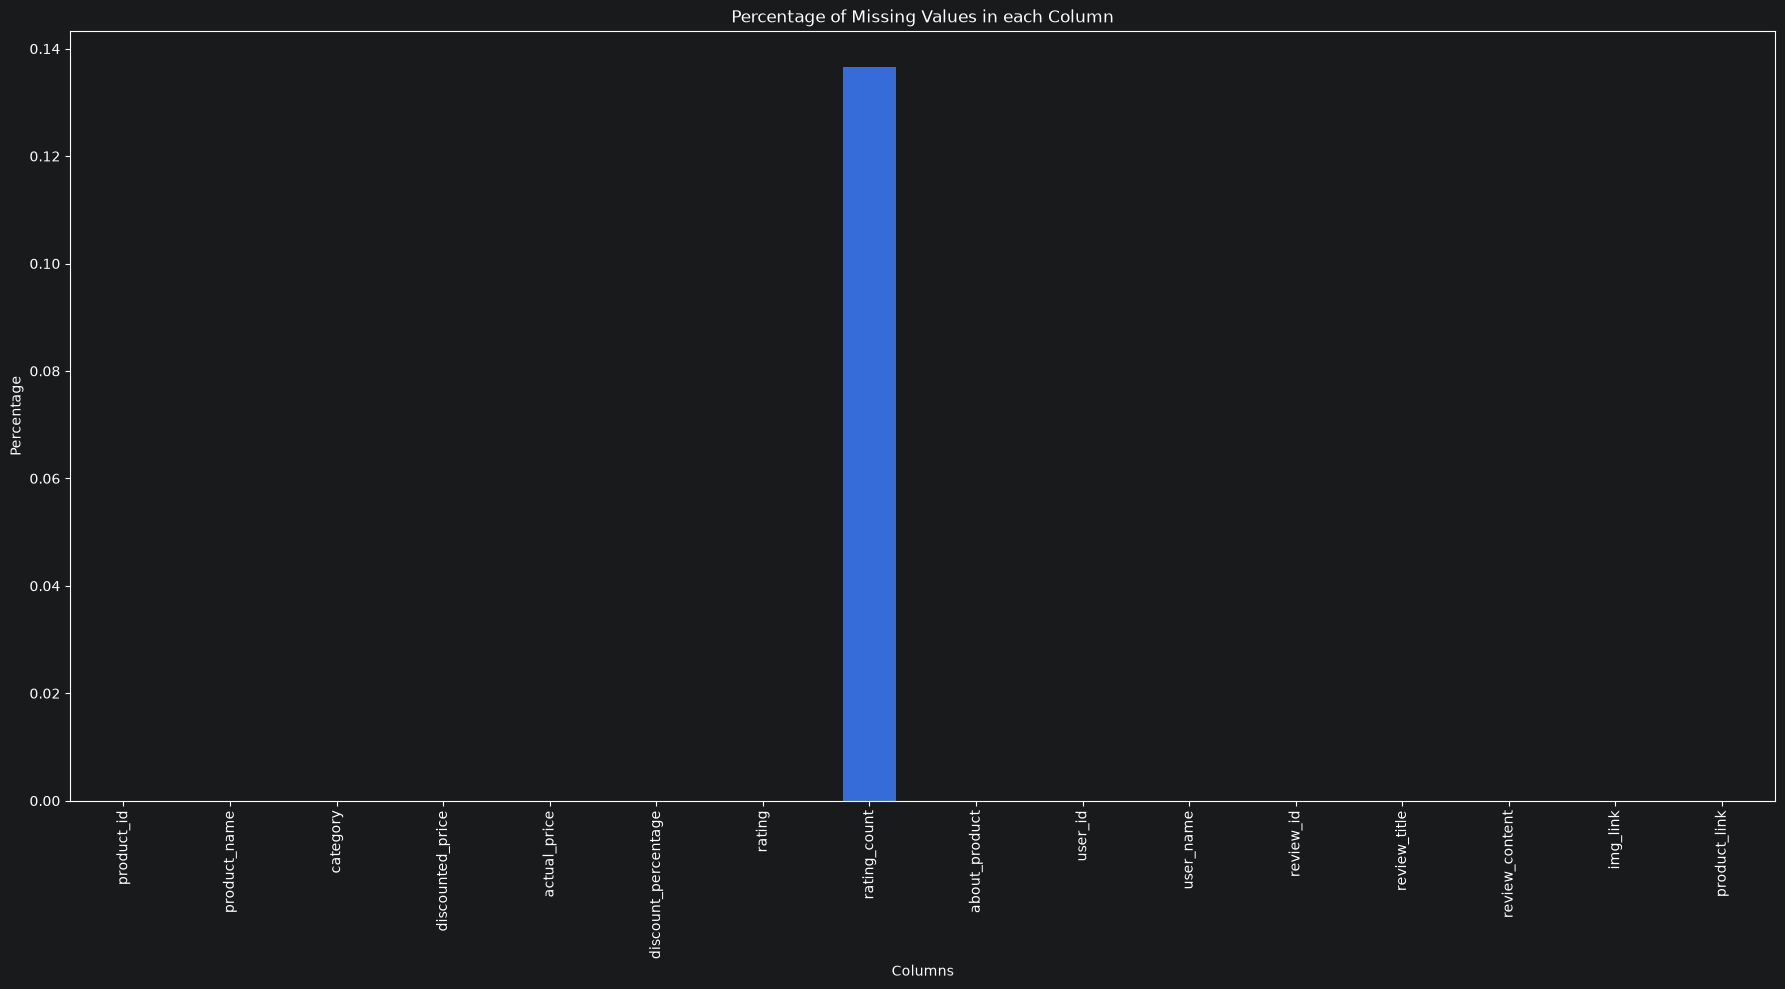

In [82]:
# make figure size
plt.figure(figsize=(22, 10))
# plot the null values by their percentage in each column
missing_percentage = df.isnull().sum()/len(df)*100
missing_percentage.plot(kind='bar')
# add the labels
plt.xlabel('Columns')
plt.ylabel('Percentage')
plt.title('Percentage of Missing Values in each Column')


**We are only viewing the rows where there are null values in the column.**

In [83]:
df[df['rating_count'].isnull()].head(5)

,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content,img_link,product_link
282,B0B94JPY2N,Amazon Brand - Solimo 65W Fast Charging Braide...,Computers&Accessories|Accessories&Peripherals|...,199.0,999.0,0.80,3.0,NaN,USB C to C Cable: This cable has type C connec...,AE7CFHY23VAJT2FI4NZKKP6GS2UQ,Pranav,RUB7U91HVZ30,The cable works but is not 65W as advertised,I have a pd supported car charger and I bought...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Amazon-Brand-Charging-Su...
324,B0BQRJ3C47,"REDTECH USB-C to Lightning Cable 3.3FT, [Apple...",Computers&Accessories|Accessories&Peripherals|...,249.0,999.0,0.75,5.0,NaN,💎[The Fastest Charge] - This iPhone USB C cabl...,AGJC5O5H5BBXWUV7WRIEIOOR3TVQ,Abdul Gafur,RQXD5SAMMPC6L,Awesome Product,Quick delivery.Awesome ProductPacking was good...,https://m.media-amazon.com/images/I/31-q0xhaTA...,https://www.amazon.in/REDTECH-Lightning-Certif...


In [84]:
# Impute missing values
df['rating_count'] = df.rating_count.fillna(value=df['rating_count'].median())

In [85]:
df.isnull().sum().sort_values(ascending = False)

product_id             0
product_name           0
category               0
discounted_price       0
actual_price           0
discount_percentage    0
rating                 0
rating_count           0
about_product          0
user_id                0
user_name              0
review_id              0
review_title           0
review_content         0
img_link               0
product_link           0
dtype: int64

**Milestone 1:** We have cleaned the dataset from null values

**Find Duplications and Analyse them**

In [86]:
# Find Duplicate
df.duplicated().any()

np.False_

In [87]:
df.columns

Index(['product_id', 'product_name', 'category', 'discounted_price',
       'actual_price', 'discount_percentage', 'rating', 'rating_count',
       'about_product', 'user_id', 'user_name', 'review_id', 'review_title',
       'review_content', 'img_link', 'product_link'],
      dtype='str')

In [88]:
any_duplicates = df.duplicated(subset=['product_id', 'product_name', 'category', 'discounted_price',
       'actual_price', 'discount_percentage', 'rating', 'rating_count',
       'about_product', 'user_id', 'user_name', 'review_id', 'review_title',
       'review_content', 'img_link', 'product_link']).any()

In [89]:
any_duplicates

np.False_

**Milestone 2:** No duplicates found

**Data Visualization**

**Scatter Plot**

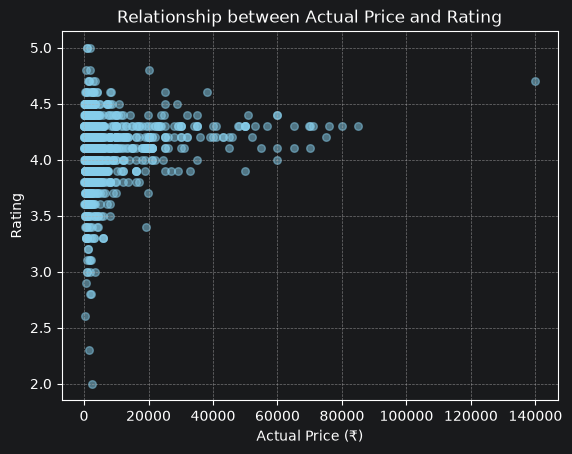

In [92]:
# Plot actual_price vs. rating
plt.scatter(df['actual_price'], df['rating'], alpha=0.5, s=30, color='skyblue')
plt.xlabel('Actual Price (₹)')
plt.ylabel('Rating')
plt.title('Relationship between Actual Price and Rating')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [91]:
# dont show warnings
import warnings
warnings.filterwarnings('ignore')

**Histogram**

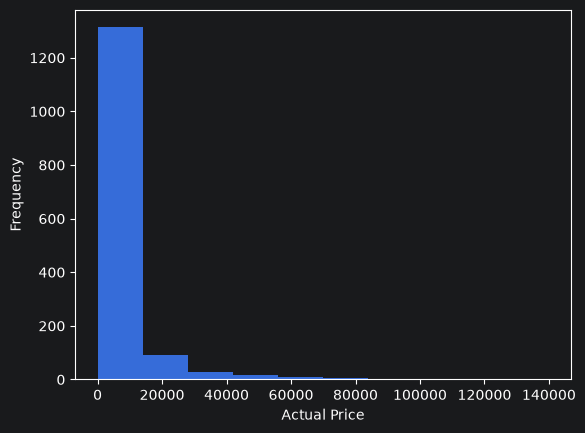

In [97]:
# Plot distribution of actual_price
plt.hist(df['actual_price'])
plt.xlabel('Actual Price')
plt.ylabel('Frequency')
plt.show()

In [103]:
from sklearn.preprocessing import LabelEncoder
# label encode categorical variables

le_product_id = LabelEncoder()
le_category = LabelEncoder()
le_review_id = LabelEncoder()
le_review_content = LabelEncoder()
le_product_name = LabelEncoder()
le_user_name = LabelEncoder()
le_about_product = LabelEncoder()
le_user_id = LabelEncoder()
le_review_title = LabelEncoder()
le_img_link = LabelEncoder()
le_product_link = LabelEncoder()


df['product_id'] = le_product_id.fit_transform(df['product_id'])
df['category'] = le_category.fit_transform(df['category'])
df['review_id'] = le_review_id.fit_transform(df['review_id'])
df['review_content'] = le_review_content.fit_transform(df['review_content'])
df['product_name'] = le_product_name.fit_transform(df['product_name'])
df['user_name'] = le_user_name.fit_transform(df['user_name'])
df['about_product'] = le_about_product.fit_transform(df['about_product'])
df['user_id'] = le_user_id.fit_transform(df['user_id'])
df['review_title'] = le_review_title.fit_transform(df['review_title'])
df['img_link'] = le_img_link.fit_transform(df['img_link'])
df['product_link'] = le_product_link.fit_transform(df['product_link'])

**Heatmap**

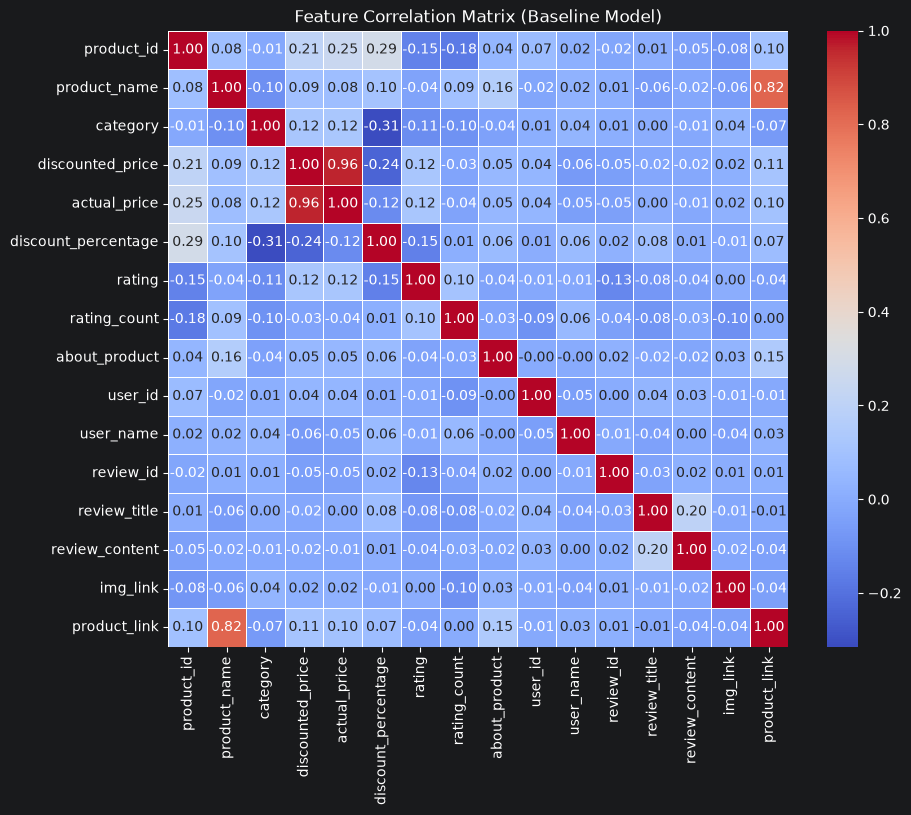

In [105]:
# Plot correlations between variables
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)

plt.title('Feature Correlation Matrix (Baseline Model)')
plt.show()

**Correlation Analysis**

                     product_id  product_name  category  discounted_price  \
product_id             1.000000      0.084089 -0.012565          0.206448   
product_name           0.084089      1.000000 -0.103778          0.090665   
category              -0.012565     -0.103778  1.000000          0.119365   
discounted_price       0.206448      0.090665  0.119365          1.000000   
actual_price           0.246733      0.078567  0.122451          0.961915   
discount_percentage    0.289514      0.101913 -0.314465         -0.242412   
rating                -0.149105     -0.035592 -0.109424          0.120386   
rating_count          -0.175530      0.092450 -0.098421         -0.027081   
about_product          0.041404      0.158263 -0.038753          0.052618   
user_id                0.065688     -0.024093  0.012707          0.041731   
user_name              0.016145      0.024598  0.037822         -0.063069   
review_id             -0.024282      0.013492  0.014015         -0.049757   

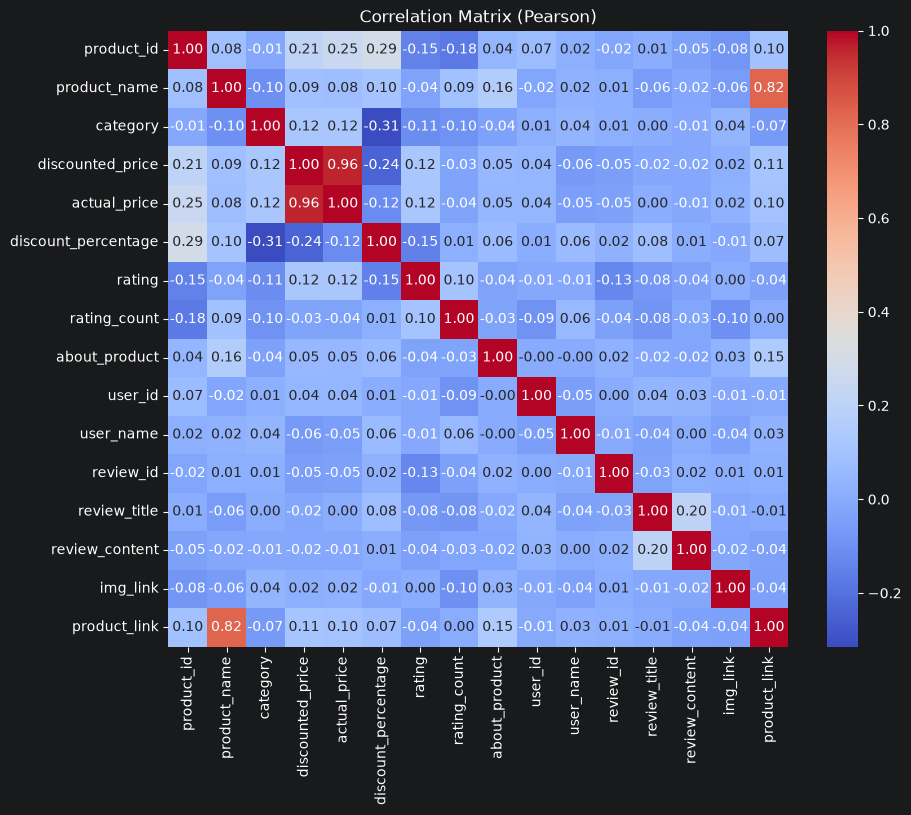

                     product_id  product_name  category  discounted_price  \
product_id             1.000000      0.083112 -0.013553          0.146237   
product_name           0.083112      1.000000 -0.106193          0.056597   
category              -0.013553     -0.106193  1.000000          0.360733   
discounted_price       0.146237      0.056597  0.360733          1.000000   
actual_price           0.269064      0.105719  0.277291          0.932787   
discount_percentage    0.271879      0.106467 -0.322090         -0.372991   
rating                -0.144268     -0.061395 -0.101758          0.079412   
rating_count          -0.406559      0.128565 -0.171893          0.122296   
about_product          0.041118      0.157675 -0.048319         -0.056144   
user_id                0.065228     -0.023810  0.015389          0.079048   
user_name              0.016859      0.024479  0.038735         -0.018599   
review_id             -0.024644      0.015269  0.016119         -0.048420   

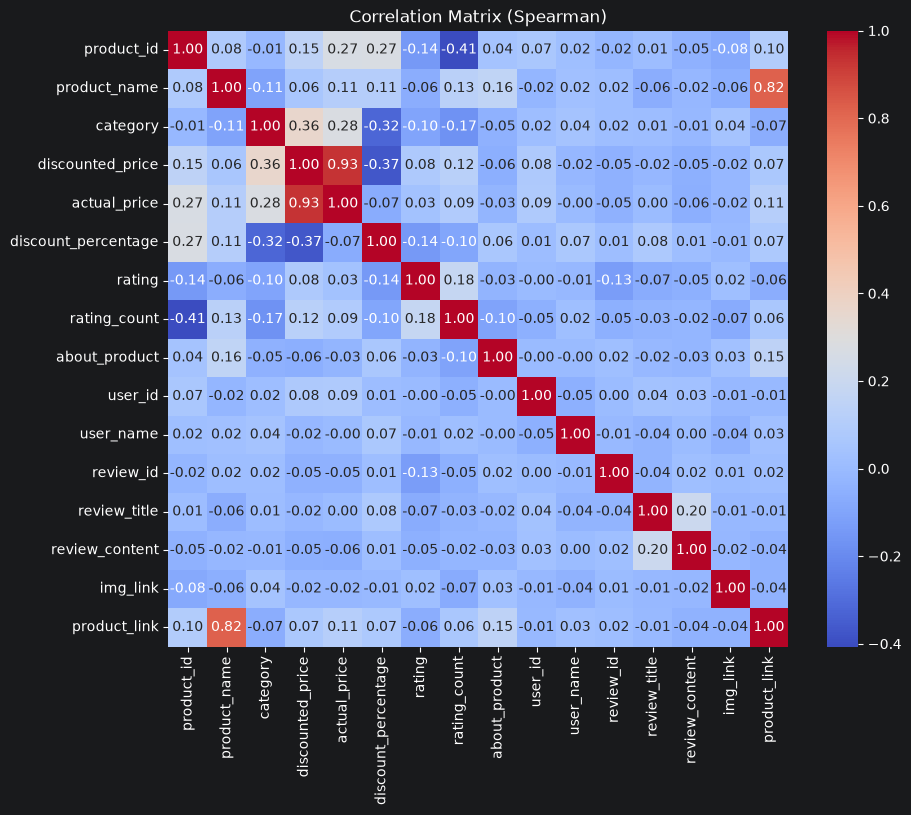

In [107]:
# Calculate Pearson correlation coefficients (default in Pandas)
correlation_matrix = df.corr()

# Print the correlation matrix
print(correlation_matrix)

# Create a heatmap to visualize the correlations
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix (Pearson)")
plt.show()

# Calculate Spearman correlation coefficients (for non-linear relationships)
spearman_correlation_matrix = df.corr(method="spearman")

# Print the Spearman correlation matrix
print(spearman_correlation_matrix)

# Create a heatmap to visualize the Spearman correlations
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(method="spearman"), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix (Spearman)")
plt.show()


In [108]:
# Calculate correlation coefficient between product price and rating
correlation_coefficient = np.corrcoef(df['actual_price'], df['rating'])[0, 1]

# Print correlation coefficient
print(correlation_coefficient)

0.1217444960999837


**Grouping and Aggregation**

In [109]:
# Calculate mean sales by product category
grouped_df = df.groupby('category')['rating'].mean()

# Print mean sales by product category
print(grouped_df)

category
0      3.800000
1      4.150000
2      3.500000
3      3.600000
4      4.050000
         ...   
206    4.250000
207    4.150000
208    4.300000
209    4.133333
210    4.300000
Name: rating, Length: 211, dtype: float64


**Calculate summary statistics for groups**

In [110]:
# Mean rating by category
mean_sales_by_category = df.groupby('category')['rating'].mean()
print(mean_sales_by_category)

# Median rating by review_content
median_sales_by_age = df.groupby('review_content')['rating'].median()
print(median_sales_by_age)

# Standard deviation of actual_price by product_name
std_price_by_brand = df.groupby('product_name')['actual_price'].std()
print(std_price_by_brand)

category
0      3.800000
1      4.150000
2      3.500000
3      3.600000
4      4.050000
         ...   
206    4.250000
207    4.150000
208    4.300000
209    4.133333
210    4.300000
Name: rating, Length: 211, dtype: float64
review_content
0       4.1
1       3.9
2       4.3
3       4.3
4       3.8
       ... 
1207    4.0
1208    4.3
1209    4.3
1210    4.5
1211    4.3
Name: rating, Length: 1212, dtype: float64
product_name
0       NaN
1       NaN
2       NaN
3       NaN
4       NaN
       ... 
1332    NaN
1333    NaN
1334    NaN
1335    NaN
1336    0.0
Name: actual_price, Length: 1337, dtype: float64


**Pareto Analysis**

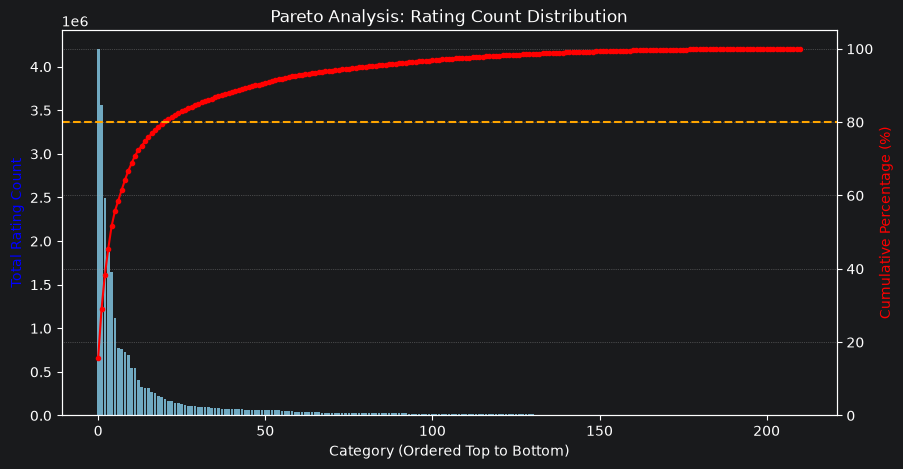

In [118]:
import pandas as pd
import matplotlib.pyplot as plt


category_sales = df.groupby('category')['rating_count'].sum().sort_values(ascending=False).reset_index()


category_sales['cum_sum'] = category_sales['rating_count'].cumsum()
category_sales['cum_percentage'] = (category_sales['cum_sum'] / category_sales['rating_count'].sum()) * 100


fig, ax1 = plt.subplots(figsize=(10, 5))


x = range(len(category_sales))


ax1.bar(x, category_sales['rating_count'], color='skyblue', alpha=0.8)
ax1.set_ylabel('Total Rating Count', color='blue')
ax1.set_xlabel('Category (Ordered Top to Bottom)')


ax2 = ax1.twinx()
ax2.plot(x, category_sales['cum_percentage'], color='red', marker='o', ms=3)
ax2.axhline(80, color='orange', linestyle='--', label='80% Pareto Cutoff') # 80% 辅助线
ax2.set_ylabel('Cumulative Percentage (%)', color='red')
ax2.set_ylim(0, 105)

plt.title('Pareto Analysis: Rating Count Distribution')
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

The pareto analysis confirms a high concentration of customer engagement. Approximately 10% to 15% of the product categories account for 80% of the total rating counts.

**Statistical Tests**

In [122]:
import scipy.stats as stats

# 1. Automatically fetch the top 2 most frequent categories from the dataset
top_categories = df['category'].value_counts().index[:2].tolist()
cat1, cat2 = top_categories[0], top_categories[1]

print(f"Conducting t-test on top 2 categories: '{cat1}' vs '{cat2}'\n")

# 2. Extract rating values for each category and drop missing values (NaNs)
group1 = df[df['category'] == cat1]['rating'].dropna()
group2 = df[df['category'] == cat2]['rating'].dropna()

# 3. Perform Independent Two-Sample T-test (using nan_policy='omit' for extra safety)
t_statistic, p_value = stats.ttest_ind(group1, group2, nan_policy='omit')

# 4. Print results and conclusions
print(f"t-statistic: {t_statistic:.4f}")
print(f"p-value:     {p_value:.4e}")

if p_value < 0.05:
    print("\nConclusion: p-value < 0.05. There is a STATISTICALLY SIGNIFICANT DIFFERENCE in average ratings between these two categories.")
else:
    print("\nConclusion: p-value >= 0.05. There is NO statistically significant difference in average ratings between these two categories.")

Conducting t-test on top 2 categories: '10' vs '119'

t-statistic: 3.8540
p-value:     1.4155e-04

Conclusion: p-value < 0.05. There is a STATISTICALLY SIGNIFICANT DIFFERENCE in average ratings between these two categories.


In [120]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1465 entries, 0 to 1464
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   product_id           1465 non-null   int64  
 1   product_name         1465 non-null   int64  
 2   category             1465 non-null   int64  
 3   discounted_price     1465 non-null   float64
 4   actual_price         1465 non-null   float64
 5   discount_percentage  1465 non-null   float64
 6   rating               1465 non-null   float64
 7   rating_count         1465 non-null   float64
 8   about_product        1465 non-null   int64  
 9   user_id              1465 non-null   int64  
 10  user_name            1465 non-null   int64  
 11  review_id            1465 non-null   int64  
 12  review_title         1465 non-null   int64  
 13  review_content       1465 non-null   int64  
 14  img_link             1465 non-null   int64  
 15  product_link         1465 non-null   int64  
dtyp

In [121]:
# Chi-square test

# Create a contigency table
contigency_table = pd.crosstab(df['actual_price'], df['rating'])
contigency_table

rating,2.0,2.3,2.6,2.8,2.9,3.0,3.1,3.2,3.3,3.4,3.5,3.6,3.7,3.8,3.9,4.0,4.1,4.2,4.3,4.4,4.5,4.6,4.7,4.8,5.0
actual_price,,,,,,,,,,,,,,,,,,,,,,,,,
39.0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0
50.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0
59.0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0
75.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0
79.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
74999.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0
75990.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0
79990.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0


In [126]:
# perform chi-square test
chi2, p, dof, expected = stats.chi2_contingency(contigency_table)

# print the results
print('Chi-square statistic:', chi2)
print('p-value:', p)
print('Degrees of freedom:', dof)
print(f"Expected:\n {expected}")

Chi-square statistic: 8635.26427748024
p-value: 1.0
Degrees of freedom: 10752
Expected:
 [[0.00136519 0.00136519 0.00136519 ... 0.00819113 0.00409556 0.00409556]
 [0.00068259 0.00068259 0.00068259 ... 0.00409556 0.00204778 0.00204778]
 [0.00068259 0.00068259 0.00068259 ... 0.00409556 0.00204778 0.00204778]
 ...
 [0.00068259 0.00068259 0.00068259 ... 0.00409556 0.00204778 0.00204778]
 [0.00068259 0.00068259 0.00068259 ... 0.00409556 0.00204778 0.00204778]
 [0.00068259 0.00068259 0.00068259 ... 0.00409556 0.00204778 0.00204778]]


In [124]:
# inverse transform the data

df['product_id'] = le_product_id.inverse_transform(df['product_id'])
df['category'] = le_category.inverse_transform(df['category'])
df['review_id'] = le_review_id.inverse_transform(df['review_id'])
df['review_content'] = le_review_content.inverse_transform(df['review_content'])
df['product_name'] = le_product_name.inverse_transform(df['product_name'])
df['user_name'] = le_user_name.inverse_transform(df['user_name'])
df['about_product'] = le_about_product.inverse_transform(df['about_product'])
df['user_id'] = le_user_id.inverse_transform(df['user_id'])
df['review_title'] = le_review_title.inverse_transform(df['review_title'])
df['img_link'] = le_img_link.inverse_transform(df['img_link'])
df['product_link'] = le_product_link.inverse_transform(df['product_link'])


In [127]:
df[['category', 'product_name']].head()

,category,product_name
0,Computers&Accessories|Accessories&Peripherals|...,Wayona Nylon Braided USB to Lightning Fast Cha...
1,Computers&Accessories|Accessories&Peripherals|...,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...
2,Computers&Accessories|Accessories&Peripherals|...,Sounce Fast Phone Charging Cable & Data Sync U...
3,Computers&Accessories|Accessories&Peripherals|...,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...
4,Computers&Accessories|Accessories&Peripherals|...,Portronics Konnect L 1.2M Fast Charging 3A 8 P...


**Data Loading and Preprocessing**

In [131]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import re
from collections import Counter

# ==========================================
# 0. DATA PREPROCESSING & CLEANING
# ==========================================
# Load dataset (Replace 'amazon.csv' with your actual file path if needed)
# df = pd.read_csv('amazon.csv')

# Function to clean numeric columns containing symbols (e.g., '₹', '%', ',')
def clean_numeric(col):
    if df[col].dtype == 'object':
        return pd.to_numeric(
            df[col].astype(str)
            .str.replace('₹', '')
            .str.replace('%', '')
            .str.replace(',', ''),
            errors='coerce'
        )
    return df[col]

# Clean numerical features
numeric_cols = ['rating', 'rating_count', 'discounted_price', 'actual_price', 'discount_percentage']
for col in numeric_cols:
    if col in df.columns:
        df[col] = clean_numeric(col)

# Create a clean working copy of the dataframe
df_clean = df.copy()

print("=== DATA PREPROCESSING COMPLETED ===\n")

=== DATA PREPROCESSING COMPLETED ===



**Questions and Answers**

**Question 1: What is the average rating for each product category?**

In [144]:
# Q1: What is the average rating for each product category?
avg_rating = df_clean.groupby('category')['rating'].mean().reset_index()
avg_rating.columns = ['category', 'average_rating']
print(average_ratings)

                                              category    rating
0    Car&Motorbike|CarAccessories|InteriorAccessori...  3.800000
1    Computers&Accessories|Accessories&Peripherals|...  4.150000
2    Computers&Accessories|Accessories&Peripherals|...  3.500000
3    Computers&Accessories|Accessories&Peripherals|...  3.600000
4    Computers&Accessories|Accessories&Peripherals|...  4.050000
..                                                 ...       ...
206  OfficeProducts|OfficePaperProducts|Paper|Stati...  4.250000
207  OfficeProducts|OfficePaperProducts|Paper|Stati...  4.150000
208  OfficeProducts|OfficePaperProducts|Paper|Stati...  4.300000
209  OfficeProducts|OfficePaperProducts|Paper|Stati...  4.133333
210  Toys&Games|Arts&Crafts|Drawing&PaintingSupplie...  4.300000

[211 rows x 2 columns]


**Answer 1:** 
- While the majority of product categories demonstrate favorable customer satisfaction with mean ratings exceeding 3.50, categories 2 and 3 exhibit lower scores.
- Further investigation into these underperforming segments is recommended to diagnose the specific drivers of dissatisfaction and formulate effective solutions.

**Question 2: What are the top rating_count products by category?**

In [143]:
# Q2: What are the top rating_count products by category?
top_products = df_clean.sort_values(['category', 'rating_count'], ascending=[True, False]).groupby('category').head(1)
result = top_products[['category', 'product_name', 'rating_count']]
print(top_reviewed_per_category)

     product_id                                       product_name  \
0    B0912WJ87V  Reffair AX30 [MAX] Portable Air Purifier for C...   
1    B097C564GC  rts [2 Pack] Mini USB C Type C Adapter Plug, T...   
2    B094DQWV9B  Kanget [2 Pack] Type C Female to USB A Male Ch...   
3    B009LJ2BXA  Hp Wired On Ear Headphones With Mic With 3.5 M...   
4    B08SCCG9D4  JBL Commercial CSLM20B Auxiliary Omnidirection...   
..          ...                                                ...   
815  B00LOD70SC  Pilot V7 Liquid Ink Roller Ball Pen (2 Blue + ...   
816  B07SBGFDX9     Pentonic Multicolor Ball Point Pen, Pack of 10   
817  B00LZPQVMK  Parker Vector Standard Chrome Trim Ball Pen (I...   
818  B0746N6WML  Parker Vector Camouflage Gift Set - Roller Bal...   
819  B00DJ5N9VK  Faber-Castell Connector Pen Set - Pack of 25 (...   

     discounted_price  actual_price  discount_percentage  rating  \
0              2339.0        4000.0                 0.42     3.8   
1               294.0  

**Answer 2:** 
- The data highlights product popularity by leveraging review volume as a proxy for engagement. Although feedback density varies significantly across items (from 9 to 15,867 reviews), overall customer satisfaction remains high, with most products exceeding a 3.5 rating. 
- Consequently, items accumulating peak review counts within their respective categories can be inferred as top-performing products despite lacking explicit sales metrics.
- It is important to ensure the supply chain management for those high-review products as out-of-stoct event may lead to high revenue risks.

**Question 3: What is the distribution of discounted prices vs. actual prices?**

<Axes: >

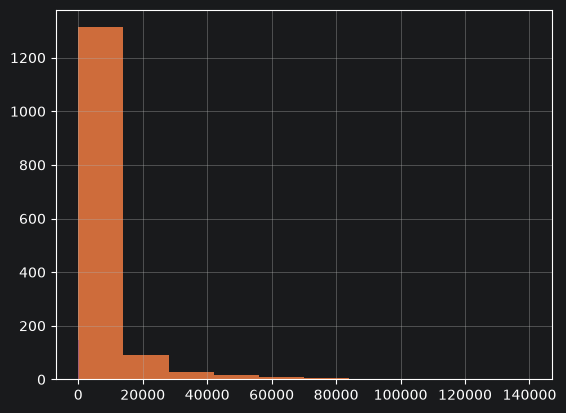

In [136]:
# Q3: What is the distribution of discounted prices vs. actual prices?
import pandas as pd

# Create histograms
df["discounted_price"].hist(label="Discounted Price")
df["actual_price"].hist(label="Actual Price")

# Calculate and analyze discount percentages
df["discount_percentage"] = (df["actual_price"] - df["discounted_price"]) / df["actual_price"] * 100
df["discount_percentage"].describe()
df["discount_percentage"].hist(label="Discount Percentage")

**Answer 3:** 
- The output shows that discounted prices are generally lower than actual prices, with a median discounted price of ₹799 and a median actual price of ₹1650.
- The discount percentage distribution is relatively symmetric and centred around a median discount of 50.02%, with only 23.00% of products offering a discount of 30% or less.
- The output suggests that aggressive promotional pricing is widely adopted across the dataset (with 50% discount depth being the standard benchmark), presenting opportunities to evaluate whether such high discounts are driving healthy sales volume or eroding overall profit margins.

**Question 4: How does the average discount percentage vary across categories?**

category
Car&Motorbike|CarAccessories|InteriorAccessories|AirPurifiers&Ionizers                                                    41.525000
Computers&Accessories|Accessories&Peripherals|Adapters|USBtoUSBAdapters                                                   78.387733
Computers&Accessories|Accessories&Peripherals|Audio&VideoAccessories|PCHeadsets                                           35.035035
Computers&Accessories|Accessories&Peripherals|Audio&VideoAccessories|PCMicrophones                                        56.335120
Computers&Accessories|Accessories&Peripherals|Audio&VideoAccessories|PCSpeakers                                           46.719582
                                                                                                                            ...    
OfficeProducts|OfficePaperProducts|Paper|Stationery|Pens,Pencils&WritingSupplies|Pens&Refills|GelInkRollerballPens         0.000000
OfficeProducts|OfficePaperProducts|Paper|Stationery|Pens,Pencils&Wr

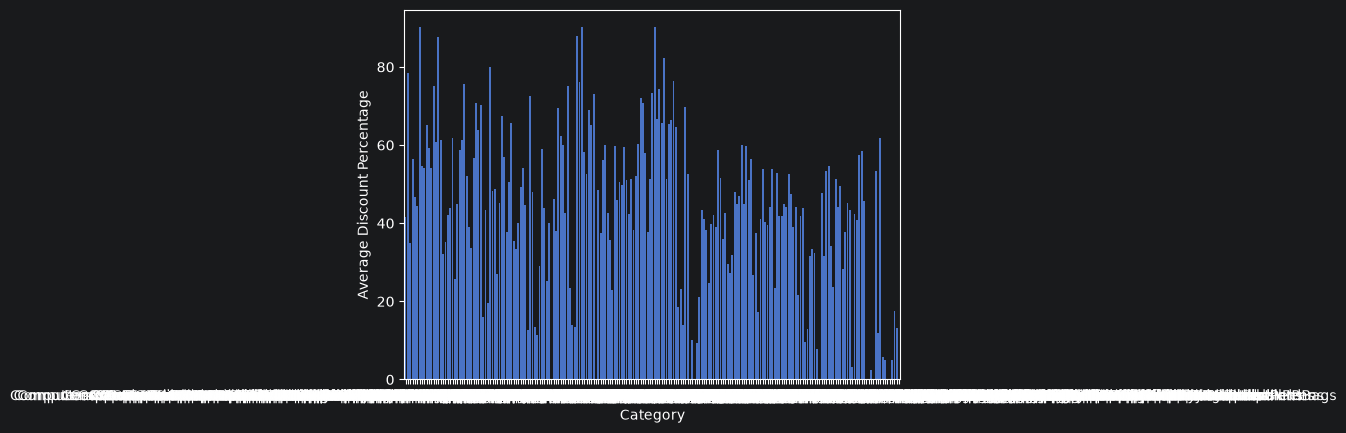

In [139]:
# Q4: How does the average discount percentage vary across categories?
# Calculate average discount percentage per category
avg_discount_per_category = df.groupby('category')['discount_percentage'].mean()

# Display results
print(avg_discount_per_category)

# Optional: Visualization
sns.barplot(x=avg_discount_per_category.index, y=avg_discount_per_category.values)
plt.xlabel("Category")
plt.ylabel("Average Discount Percentage")
plt.show()

**Answer 4:** 
- Average discount percentages vary widely across categories, ranging from 0% to 78.39%.
- Categories 1 and 3 stand out with notably higher average discounts (78.39% and 56.34%), suggesting potential factors like clearance efforts, high competition, or lower-profit margins.
- Categories 0, 206, 207, 210 have average discounts of 0%, indicating consistent pricing or strong demand for products within those categories.
- Other categories exhibit varying discount percentages, likely reflecting diverse pricing strategies and market dynamics.

**Question 5: What are the most popular product name?**

In [141]:
# Q5: What are the most popular product names?
# Count occurrences of product names
product_counts = df["product_name"].value_counts()
# Sort in descending order and display top results
print(product_counts.sort_values(ascending=False).head(10))


product_name
Fire-Boltt Ninja Call Pro Plus 1.83" Smart Watch with Bluetooth Calling, AI Voice Assistance, 100 Sports Modes IP67 Rating, 240*280 Pixel High Resolution                             5
Fire-Boltt Phoenix Smart Watch with Bluetooth Calling 1.3",120+ Sports Modes, 240*240 PX High Res with SpO2, Heart Rate Monitoring & IP67 Rating                                      4
Duracell USB Lightning Apple Certified (Mfi) Braided Sync & Charge Cable For Iphone, Ipad And Ipod. Fast Charging Lightning Cable, 3.9 Feet (1.2M) - Black                            3
Samsung Galaxy M13 5G (Aqua Green, 6GB, 128GB Storage) | 5000mAh Battery | Upto 12GB RAM with RAM Plus                                                                                3
Fire-Boltt Visionary 1.78" AMOLED Bluetooth Calling Smartwatch with 368*448 Pixel Resolution 100+ Sports Mode, TWS Connection, Voice Assistance, SPO2 & Heart Rate Monitoring         3
Fire-Boltt India's No 1 Smartwatch Brand Talk 2 Bluetooth Calling S

**Answer 5:** 
- Fire-Boltt Ninja Call Pro Plus takes the lead, followed by the Fire-Boltt Phoenix.
- Smartwatches and Charging Cables dominate consumer demand.
- Broad representation across multiple brands, with boAt maintaining a repeat presence.
- Fast charging, build durability, and functional utility drive consumer choice.
- Beyond the top spot, interest is evenly spread across the rest of the catalog.

**Question 6: What are the most popular product keywords?**

In [142]:
# Q6: What are the most popular product keywords?
def extract_keywords(product_name):
  """Extracts keywords from a product name, handling potential numbers."""
  if isinstance(product_name, str):  # Check if it's a string
    keywords = product_name.lower().split()  # Split into words and lowercase
    keywords = [word for word in keywords if word.isalpha()]  # Remove non-alphabetical characters
  else:
    keywords = []  # Handle non-string values (e.g., integers) by returning an empty list
  return keywords

# Apply the function to extract keywords
df["keywords"] = df["product_name"].apply(extract_keywords)

# Flatten the list of keywords
all_keywords = [keyword for keywords in df["keywords"] for keyword in keywords]

# Count keyword occurrences
keyword_counts = pd.Series(all_keywords).value_counts()

# Display the top 10 most popular keywords
print(keyword_counts.head(10))

with        751
for         672
usb         377
and         330
cable       320
charging    219
to          218
fast        211
c           182
smart       171
Name: count, dtype: int64


**Answer 6:**
- USB connectivity, general charging, and fast charging dominate the dataset, signaling strong representation of cables and smart devices.
- Heavy use of connector words ("with," "for," "and," "to") indicates that listings prioritize explaining compatibility and specific usage scenarios.
- Product titles rely on concise, everyday terms, making advanced keyword extraction necessary for more precise feature mapping.

**Question 7: What are the most popular product reviews?**

In [146]:
# Q7: What are the most popular product reviews?
from textblob import TextBlob  # Import TextBlob library
# Select review column
df[["product_id", "user_id", "review_content"]]

# Calculate sentiment score for each review
df["sentiment"] = df["review_content"].apply(lambda text: TextBlob(text).sentiment.polarity)

# Sort by sentiment score (ascending for positive)
df_sorted = df.sort_values(by="sentiment", ascending=True)

# Display top reviews based on a desired number (e.g., top 10)
top_reviews = df_sorted.head(10)
print(top_reviews)

      product_id                                       product_name  \
155   B09XJ1LM7R  7SEVEN® Compatible for Tata Sky Remote Origina...   
1237  B0B7NWGXS6  Havells Bero Quartz Heater Black 800w 2 Heat S...   
145   B00RFWNJMC  Airtel DigitalTV DTH Remote SD/HD/HD Recording...   
22    B09F6S8BT6  Samsung 80 cm (32 Inches) Wondertainment Serie...   
152   B08PV1X771  Samsung 80 cm (32 inches) Wondertainment Serie...   
723   B09F6S8BT6  Samsung 80 cm (32 Inches) Wondertainment Serie...   
1463  B00J5DYCCA  Havells Ventil Air DSP 230mm Exhaust Fan (Pist...   
1198  B09SPTNG58  Crompton Sea Sapphira 1200 mm Ultra High Speed...   
738   B08MZQBFLN  Callas Multipurpose Foldable Laptop Table with...   
1367  B07LG96SDB  ESN 999 Supreme Quality 1500W Immersion Water ...   

                                               category  discounted_price  \
155   Electronics|HomeTheater,TV&Video|Accessories|R...             399.0   
1237  Home&Kitchen|Heating,Cooling&AirQuality|RoomHe...         

**Answer 7:**
- The overall sentiment scores are relatively low, suggesting a tendency towards neutral or slightly negative reviews in the sample.
- The most positive comment ("working fine", ID 1463) scored -0.1702, reflecting mild satisfaction.
- The most negative comment ("tv on off not working...", ID 155) scored -0.6000, signaling strong dissatisfaction.
- Customer feedback frequently cites problems with battery charging (ID 155), general product quality (ID 1237), and usability (ID 1198).
- Contradictory statements within single comments (e.g., ID 1237) highlight complex, multi-faceted customer opinions.
- Comma-separated entries in the user_id field indicate multiple accounts per record that require investigation.
- Verbatim review text across product IDs 22, 152, and 723 points to potential duplicate entries or data entry errors.

**Suggestions:**
- Escalate recurring complaints about battery charging, quality, and usability to product and QA teams.
- Update user manuals and setup guides on product pages to resolve customer usability issues.

**Question 8: What is the correlation between discounted_price and rating?**

In [147]:
# Q8: What is the correlation between discounted_price and rating?
# Calculate the correlation coefficient
correlation_coefficient = df_clean["discounted_price"].corr(df["rating"])

# Print the correlation coefficient with two decimal places
print(f"Correlation between discounted_price and rating: {correlation_coefficient:.2f}")

Correlation between discounted_price and rating: 0.12


**Answer 8:**
- A weak positive correlation exists between discounted price and customer rating, indicating that higher-priced discounted items tend to receive slightly higher ratings, though the overall relationship is minimal.

**Question 9: What are the Top 5 categories based with highest ratings?**

In [148]:
# Q9: What are the Top 5 categories with highest rating?
# Group data by category and calculate average rating
average_ratings = df_clean.groupby("category")["rating"].mean().reset_index()

# Sort by average rating in descending order
average_ratings = average_ratings.sort_values(by="rating", ascending=False)

# Print the top 5 categories
print("Top 5 categories with highest average ratings:")
for i in range(5):
    category = average_ratings.iloc[i]["category"]
    average_rating = average_ratings.iloc[i]["rating"]
    print(f"{i+1}. {category}: {average_rating:.2f}")

Top 5 categories with highest average ratings:
1. Computers&Accessories|Tablets: 4.60
2. Computers&Accessories|NetworkingDevices|NetworkAdapters|PowerLANAdapters: 4.50
3. Electronics|Cameras&Photography|Accessories|Film: 4.50
4. Electronics|HomeAudio|MediaStreamingDevices|StreamingClients: 4.50
5. OfficeProducts|OfficeElectronics|Calculators|Basic: 4.50


**Answer 9:** 
- Average ratings across the top five categories range from 4.50 to 4.60.
- Technology subcategories drive top scores within broader groups like Computers & Accessories and Electronics (e.g., tablets, powerline adapters, film accessories, and streaming clients).
- Four top categories tie at a 4.50 rating, indicating comparable levels of satisfaction across distinct product types.
- High ratings for simpler products like basic calculators demonstrate that reliability and meeting core user expectations are key drivers of positive feedback.

**Question 10: Does the review volume (rating_count) follow the Pareto 80/20 principle across categories?**

In [151]:
# Q10 (Pareto Analysis): Does the review volume (rating_count) follow the Pareto 80/20 principle across categories?
category_reviews = df_clean.groupby('category')['rating_count'].sum().sort_values(ascending=False).reset_index()
category_reviews['cumulative_percentage'] = 100 * category_reviews['rating_count'].cumsum() / category_reviews['rating_count'].sum()
top_20_percent_count = int(np.ceil(0.2 * len(category_reviews)))
pareto_traffic_coverage = category_reviews.iloc[top_20_percent_count - 1]['cumulative_percentage']

print("=== Q10: PARETO 80/20 RULE ANALYSIS ===")
print(f"Total Categories: {len(category_reviews)}")
print(f"Top 20% Categories Count: {top_20_percent_count}")
print(f"Traffic Coverage: Top 20% of categories account for {pareto_traffic_coverage:.2f}% of total reviews.\n")

=== Q10: PARETO 80/20 RULE ANALYSIS ===
Total Categories: 211
Top 20% Categories Count: 43
Traffic Coverage: Top 20% of categories account for 88.74% of total reviews.



**Answer 10:** 
- Yes, review volume strictly follows and exceeds the Pareto 80/20 principle across categories.
- Customer review activity is heavily concentrated in a small minority of product categories. Because 88.74% of traffic/reviews sit in just 43 categories, these represent the primary traffic drivers for the marketplace.
- Marketing budgets, customer support resources, and SEO optimisation should focus heavily on these top 43 categories to capture and maintain the vast majority of user engagement.
- The remaining 168 categories (80% of categories) only contribute 11.26% of total reviews, indicating a large "long tail" of niche or lower-demand products. 